# 📊 LDH Adsorption – EDA & PCA Analysis
**Dataset:** Micropollutant adsorption trên vật liệu LDH (Layered Double Hydroxide)  
**Mục tiêu:** EDA → PCA compression → Feature engineering → Gradient Boosting (RR% & Qe mg/g)

---
### Cấu trúc notebook
1. Import & Load dữ liệu
2. Tiền xử lý & Chuẩn hóa
3. EDA tổng quan
4. EDA theo nhóm
5. PCA – Micropollutant features (Log Kow, MW, E, S, A, B, V)
6. PCA – Material texture features (BET, PV, APD, pHpzc)
7. Correlation analysis sau PCA
8. Model – Gradient Boosting (RR% & Qe)
9. Feature Importance

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [34]:
!pip install boruta borutashap-modern cubist optuna lightgbm

## 1. Import thư viện & Load dữ liệu

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from cubist import Cubist
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_validate, cross_val_score
from sklearn.feature_selection import SequentialFeatureSelector as SFS
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.inspection import permutation_importance

from boruta import BorutaPy
from BorutaShap import BorutaShap

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'axes.titleweight' : 'bold',
    'axes.titlesize'   :  12,
})

SEED = 10
print('✅ Thư viện đã import xong')

✅ Thư viện đã import xong


In [5]:
# Load dữ liệu
FILE_PATH = '/content/drive/MyDrive/Green-X Project/Data/20260804_Data_Adsorption.xlsx'
df_raw = pd.read_excel(FILE_PATH, sheet_name=0, header=1)   # header nằm ở row 2

print(f'Shape gốc: {df_raw.shape}')
print(f'Cột: {df_raw.columns.tolist()}')

Shape gốc: (1342, 32)
Cột: ['Id', 'TP', 'Log Kow', 'MW g/mol', 'E', 'S', 'A', 'B', 'V', 'TSPA', 'Metal(II) ', 'Metal(III)', 'M(II)/(III)', 'average atomic weight (g/mol)', 'average d-electron', 'average Pauling electronegativity', 'Method', 'TemH oC', 'HT hour', 'Calcination Temp ', 'Calcination time', 'd(003) nm', 'BET m2/g', 'PV cm3/g', 'APD nm', 'pHpzc', 'pH', 'Tem', 'Time h', 'AD g/L', 'Ci mg/L', 'RR %']


In [6]:
df_raw.head(5)

,Id,TP,Log Kow,MW g/mol,E,S,A,B,V,TSPA,...,BET m2/g,PV cm3/g,APD nm,pHpzc,pH,Tem,Time h,AD g/L,Ci mg/L,RR %
0,Amir M. Ramezani_2024,Doxycycline,-0.02,444.43,2.1,3.05,1.55,1.7,2.86,181.62,...,45.17,0.524,46.37,6.9,6.0,25.0,1.000000,0.4,50.0,0.680
1,Amir M. Ramezani_2024,Doxycycline,-0.02,444.43,2.1,3.05,1.55,1.7,2.86,181.62,...,45.17,0.524,46.37,6.9,6.0,25.0,0.083333,0.4,50.0,0.120
2,Amir M. Ramezani_2024,Doxycycline,-0.02,444.43,2.1,3.05,1.55,1.7,2.86,181.62,...,45.17,0.524,46.37,6.9,6.0,25.0,0.166667,0.4,50.0,0.200
3,Amir M. Ramezani_2024,Doxycycline,-0.02,444.43,2.1,3.05,1.55,1.7,2.86,181.62,...,45.17,0.524,46.37,6.9,6.0,25.0,0.250000,0.4,50.0,0.360
4,Amir M. Ramezani_2024,Doxycycline,-0.02,444.43,2.1,3.05,1.55,1.7,2.86,181.62,...,45.17,0.524,46.37,6.9,6.0,25.0,0.333333,0.4,50.0,0.456


## 2. Tiền xử lý & Chuẩn hóa
- remove unnecessary columns, fill missing value by KNN
- Preprocess numeric columns, encode categorical data


### 2.1 Preprocessing

In [7]:
df = df_raw.copy()

# Xoá dấu cách ở tên cột
df.columns = df.columns.str.strip()

# Chuẩn hóa biến dạng categorical
df['TP'] = df['TP'].astype(str).str.strip()
df['Metal(II)'] = df['Metal(II)'].astype(str).str.strip().str.title()
df['Metal(III)'] = df['Metal(III)'].astype(str).str.strip()

# Gộp Method không nhất quán
method_map = {
    'urea hydrolysis': 'Urea Hydrolysis',
    'urea Hydrolysis': 'Urea Hydrolysis',
    'co-precipitation or aging': 'Co-precipitation',
    'co-precipitation': 'Co-precipitation',
    'co- precipitation': 'Co-precipitation',
    'reconstruction or memory effect': 'Reconstruction',
}
df['Method'] = df['Method'].astype(str).str.strip().str.lower()
df['Method'] = df['Method'].replace(method_map)
df['Method'] = df['Method'].str.title()  # fallback

# Xử lý RR% (percentage format)
df['RR %'] = df['RR %'] * 100

# Remove unnecessary columns
df = df.drop(columns=["Id"])

# Display tables
print(f"RR% range: [{df['RR %'].min():.3f}, {df['RR %'].max():.3f}]")
display(df.head(5))

RR% range: [0.000, 100.000]


,TP,Log Kow,MW g/mol,E,S,A,B,V,TSPA,Metal(II),...,BET m2/g,PV cm3/g,APD nm,pHpzc,pH,Tem,Time h,AD g/L,Ci mg/L,RR %
0,Doxycycline,-0.02,444.43,2.1,3.05,1.55,1.7,2.86,181.62,Zn,...,45.17,0.524,46.37,6.9,6.0,25.0,1.000000,0.4,50.0,68.0
1,Doxycycline,-0.02,444.43,2.1,3.05,1.55,1.7,2.86,181.62,Zn,...,45.17,0.524,46.37,6.9,6.0,25.0,0.083333,0.4,50.0,12.0
2,Doxycycline,-0.02,444.43,2.1,3.05,1.55,1.7,2.86,181.62,Zn,...,45.17,0.524,46.37,6.9,6.0,25.0,0.166667,0.4,50.0,20.0
3,Doxycycline,-0.02,444.43,2.1,3.05,1.55,1.7,2.86,181.62,Zn,...,45.17,0.524,46.37,6.9,6.0,25.0,0.250000,0.4,50.0,36.0
4,Doxycycline,-0.02,444.43,2.1,3.05,1.55,1.7,2.86,181.62,Zn,...,45.17,0.524,46.37,6.9,6.0,25.0,0.333333,0.4,50.0,45.6


### 2.2 Missing values

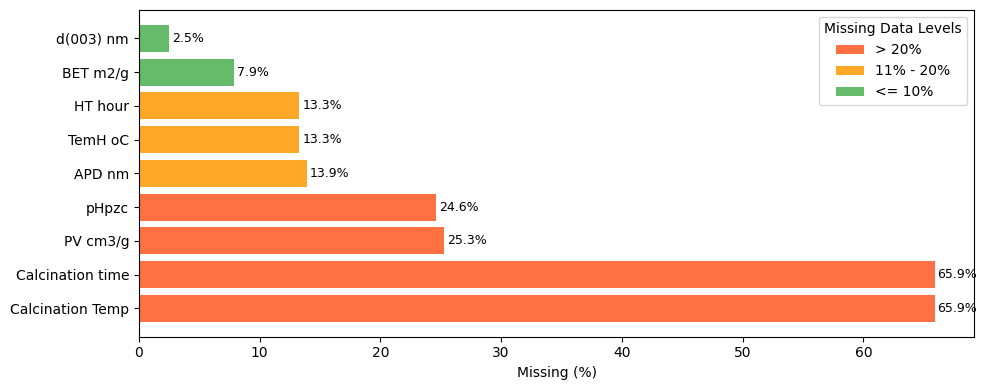

In [8]:
TARGET_COLS = ["RR %"]
FEATURE_COLS = [col for col in df.columns.to_list() if col not in TARGET_COLS]

# Missign statistic distribution
miss = df[FEATURE_COLS].isnull().sum()
miss_pct = (miss / len(df) * 100).round(1)

miss_df = pd.DataFrame({'Missing count': miss, 'Missing %': miss_pct})
miss_df = miss_df[miss_df['Missing count'] > 0].sort_values('Missing %', ascending=False)

# Visualize
if len(miss_df) > 0:
    # Plot setup
    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.barh(miss_df.index, miss_df['Missing %'],
                   color=['#FF7043' if v > 20 else '#FFA726' if v > 10 else '#66BB6A'
                          for v in miss_df['Missing %']])
    ax.set_xlabel('Missing (%)')
    for bar, val in zip(bars, miss_df['Missing %']):
        ax.text(val + 0.25, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9)

    # Define the custom legend elements
    legend_elements = [
        Patch(facecolor='#FF7043', label='> 20%'),
        Patch(facecolor='#FFA726', label='11% - 20%'),
        Patch(facecolor='#66BB6A', label='<= 10%')
    ]

    # Add the legend to the graph
    ax.legend(handles=legend_elements, title='Missing Data Levels', loc='upper right')

    plt.tight_layout()
    plt.savefig("/content/drive/MyDrive/Green-X Project/Model/missing_values.png", dpi=300)
    plt.show()
else:
    print('No missing values in all columns')

## 3. EDA – Tổng quan

Summary statistics of variables using for predictive models

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1342 entries, 0 to 1341
Data columns (total 31 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   TP                                 1342 non-null   object 
 1   Log Kow                            1342 non-null   float64
 2   MW g/mol                           1342 non-null   float64
 3   E                                  1342 non-null   float64
 4   S                                  1342 non-null   float64
 5   A                                  1342 non-null   float64
 6   B                                  1342 non-null   float64
 7   V                                  1342 non-null   float64
 8   TSPA                               1342 non-null   float64
 9   Metal(II)                          1342 non-null   object 
 10  Metal(III)                         1342 non-null   object 
 11  M(II)/(III)                        1342 non-null   float

Type of micropollutants and their corresponding equilibrium adsorption capacity

In [10]:
adsorption_df = df.groupby("TP").agg(
    RR_mean=("RR %", "mean"),
    n=("Log Kow", "size"),
    Log_Kow_mean=("Log Kow", "mean"),
    MW_mean=("MW g/mol", "mean"),
    E_mean=("E", "mean"),
    S_mean=("S", "mean"),
    A_mean=("A", "mean"),
    B_mean=("B", "mean"),
    V_mean=("V", "mean")
).reset_index()

display(adsorption_df)

,TP,RR_mean,n,Log_Kow_mean,MW_mean,E_mean,S_mean,A_mean,B_mean,V_mean
0,Amoxicillin,38.847193,94,-2.67,365.41,2.200000,2.600000,0.900000,1.700000,2.538500
1,Ciprofloxacin,42.825394,181,0.28,331.34,2.200000,2.340000,0.700000,2.520000,2.304700
2,Delafloxacin,71.330435,23,1.70,440.40,1.800000,2.200000,0.800000,1.100000,3.300000
3,Diclofenac,42.392270,304,4.51,318.13,1.810000,1.850000,0.550000,0.770000,2.025000
4,Doxycycline,49.388472,106,-0.02,444.43,2.100000,3.050000,1.550000,1.700000,2.860000
5,Erythromycin,49.147045,22,3.06,733.93,1.720000,2.650000,1.550000,3.100000,6.350000
6,Ibuprofen,69.961795,39,3.50,206.29,0.729231,0.705128,0.561026,0.784615,1.777087
7,Levofloxacin,54.642163,102,-0.25,361.37,1.650000,2.100000,0.700000,1.400000,2.504300
8,Methylparaben,67.667857,56,1.96,152.15,0.900000,1.370000,0.690000,0.450000,1.131300
9,Metronidazole,32.225888,81,-0.02,171.15,1.120000,1.750000,0.310000,0.860000,1.191900


Text(1.1, 20.875, 'Q1=20.875')

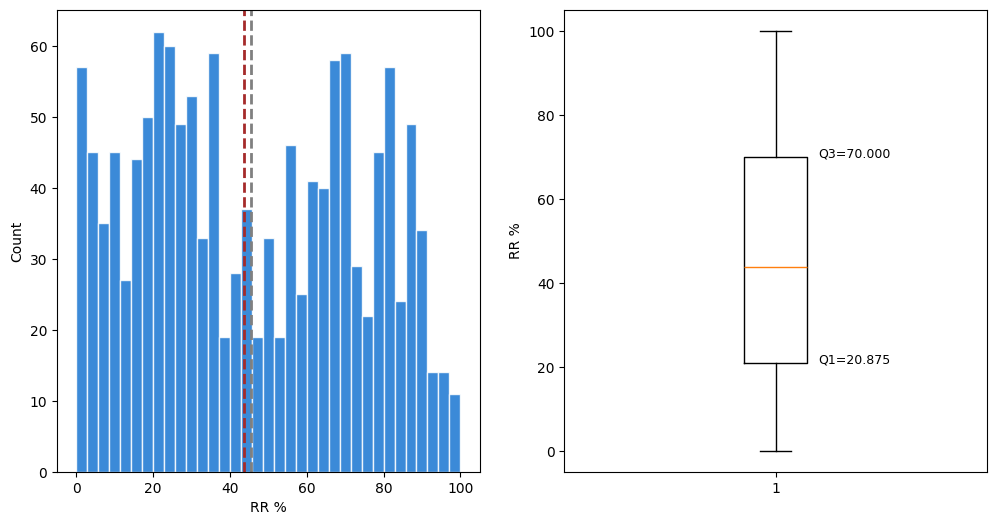

In [11]:
# Phân phối 2 biến mục tiêu
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# RR % – gốc
ax = axes[0]
ax.hist(df['RR %'].dropna(), bins=35, color='#1976D2', edgecolor='white', alpha=0.85)
ax.axvline(df['RR %'].mean(), color='gray', ls='--', lw=2,
           label=f"Mean = {df['RR %'].mean():.3f}")
ax.axvline(df['RR %'].median(), color='brown', ls='--', lw=2,
           label=f"Median = {df['RR %'].median():.3f}")
ax.set_xlabel('RR %'); ax.set_ylabel('Count')

# RR % – boxplot
ax = axes[1]
bp = ax.boxplot(df['RR %'].dropna(), vert=True, patch_artist=False)
ax.set_ylabel('RR %')
stats_rr = df['RR %'].describe()
ax.text(1.1, stats_rr['75%'], f"Q3={stats_rr['75%']:.3f}", fontsize=9)
ax.text(1.1, stats_rr['25%'], f"Q1={stats_rr['25%']:.3f}", fontsize=9)

## 4. EDA – Phân tích theo nhóm

In [12]:
# Nhóm A – Micropollutant descriptors
MICRO_COLS = ['Log Kow', 'MW g/mol', 'E', 'S', 'A', 'B', 'V', 'TSPA']

# Nhóm B – Material texture
MAT_COLS = ['d(003) nm', 'BET m2/g', 'PV cm3/g', 'APD nm', 'pHpzc']

# Nhóm C – Adsorbent properties
COMPO_COLS = ['M(II)/(III)', 'average atomic weight (g/mol)', 'average d-electron', 'average Pauling electronegativity']

# Nhóm D - Điều kiện tổng hợp vật liệu
SYNTH_COLS = ['TemH oC', 'HT hour', 'Calcination Temp', 'Calcination time']

# Nhóm D – Điều kiện thí nghiệm
EXP_COLS = ['pH', 'Tem', 'Time h', 'AD g/L', 'Ci mg/L']

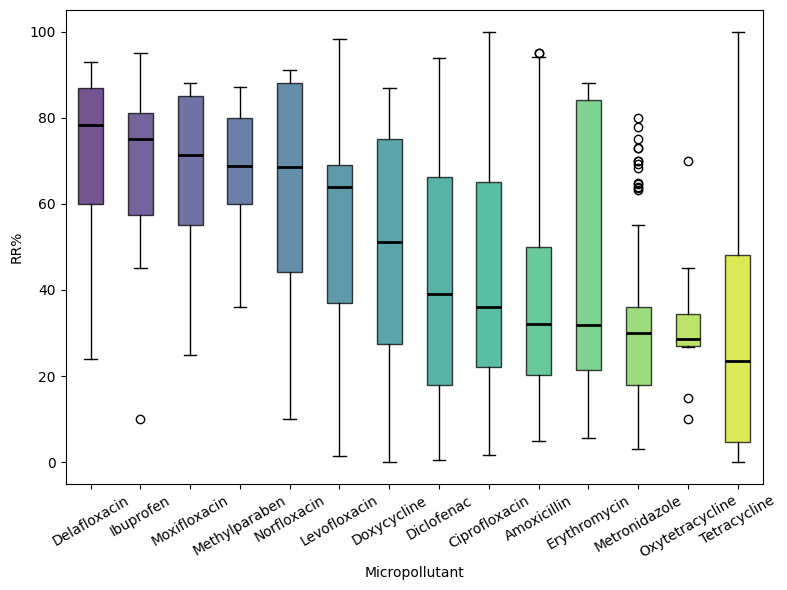

In [13]:
# RR% theo từng Micropollutant
fig, ax = plt.subplots(figsize=(8, 6))
# Order of micropollutant
order = df.groupby('TP')['RR %'].median().sort_values(ascending=False).index
# Color pallete
palette = sns.color_palette('viridis', len(order))

bp = ax.boxplot(
    [df[df['TP']==tp]['RR %'].dropna().values for tp in order],
    patch_artist=True, labels=order,
    medianprops=dict(color='black', lw=2)
)
for patch, c in zip(bp['boxes'], palette):
    patch.set_facecolor(c); patch.set_alpha(0.75)
ax.set_ylabel('RR%'); ax.set_xlabel('Micropollutant')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

## 5. Feature Engineering

In [14]:
# Clone a copy
df_imputed = df.copy()
# Drop experimental columns before training
df_imputed = df_imputed.drop(columns=['TP', 'Metal(II)', 'Metal(III)', 'Method', 'TemH oC', 'HT hour', 'Calcination Temp', 'Calcination time'])
# Split to X and y
X = df_imputed.drop(TARGET_COLS, axis=1).copy()
y = df_imputed[TARGET_COLS].copy()
# Convert targets to array
y_rr = np.array(y)
# Divide data to avoid leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=SEED)

### 5.1 KNN Imputation

In [16]:
cols_to_impute = [
    'd(003) nm', 'BET m2/g', 'APD nm', 'pHpzc', 'PV cm3/g'
]
# Standardize before KNN
scaler = StandardScaler()
scaler.fit(X_train[cols_to_impute])
# Apply on train and test
X_train[cols_to_impute] = scaler.transform(X_train[cols_to_impute])
X_test[cols_to_impute] = scaler.transform(X_test[cols_to_impute])

# Innitialize KNN Imputer
knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
knn_imputer.fit(X_train[cols_to_impute])
# Apply on train and test
train_imputed_values = knn_imputer.transform(X_train[cols_to_impute])
test_imputed_values = knn_imputer.transform(X_test[cols_to_impute])

# Inverse transform values
train_original_values = scaler.inverse_transform(train_imputed_values)
test_original_values = scaler.inverse_transform(test_imputed_values)

# Gán lại mảng giá trị đã điền hoàn chỉnh vào DataFrame
X_train[cols_to_impute] = train_imputed_values
X_test[cols_to_impute] = test_imputed_values

print("--- CHECK NULL VALUES IN TRAIN ---")
print(X_train.isnull().sum())

print("--- CHECK NULL VALUES IN TEST ---")
print(X_test.isnull().sum())

--- CHECK NULL VALUES IN TRAIN ---
Log Kow                              0
MW g/mol                             0
E                                    0
S                                    0
A                                    0
B                                    0
V                                    0
TSPA                                 0
M(II)/(III)                          0
average atomic weight (g/mol)        0
average d-electron                   0
average Pauling electronegativity    0
d(003) nm                            0
BET m2/g                             0
PV cm3/g                             0
APD nm                               0
pHpzc                                0
pH                                   0
Tem                                  0
Time h                               0
AD g/L                               0
Ci mg/L                              0
dtype: int64
--- CHECK NULL VALUES IN TEST ---
Log Kow                              0
MW g/mol             

### 5.2 Categorical Encoding

In [17]:
CAT_COLS = X_train.select_dtypes(include=["object"]).columns.to_list()

# Label encoded categorical features
le_dict = {}
for col in CAT_COLS:
    le = LabelEncoder()
    le.fit(X_train[col])
    # Apply on train and test
    X_train[col] = le.transform(X_train[col])
    X_test[col] = le.transform(X_test[col])
    le_dict[col] = le

### 5.3 Highly-correlated features: Variance Inflator Factor
Evaluate impact of other features on RR%, not other way around to remmove target leakage

👉 Keep Metal(II) and average d-electron so the model know categorical name and a specific numerical characteristics -> remove other "average Pauling electronegativity", "average atomic weight".

👉 Keep BET m2/g and drop PV cm3/g
In porous materials like LDHs, Specific Surface Area (BET) and Total Pore Volume (PV) are physically and mathematically linked during nitrogen adsorption analysis.


👉 Keep MW g/mol (or Log Kow) and drop V, TSPA, S, A, B, E.
All of these variables describe the physical size, shape, and polarity of the target pollutant. As a molecule gets heavier (MW), its volume (V) naturally increases. Its polar surface area (TSPA) and Abraham solvation parameters (S, A, B, E) also shift in highly predictable ways based on that size and structure.


In [18]:
vif_results = {}

# Iterate over all columns in X_train to compute VIF for each
for feature_col in X_train.columns:

    y_vif = X_train[feature_col]
    X_vif = X_train.drop(columns=[feature_col])

    linreg = LinearRegression()
    linreg.fit(X_vif, y_vif)

    r_squared = linreg.score(X_vif, y_vif)

    if np.isclose(1 - r_squared, 0):
        vif_score = np.inf
    else:
        vif_score = 1 / (1 - r_squared)

    vif_results[feature_col] = vif_score

vif_df = pd.DataFrame(list(vif_results.items()), columns=["Feature", "VIF"])
vif_df.sort_values(by=["VIF"], ascending=False, inplace=True)

display(vif_df)

,Feature,VIF
6,V,116.566472
1,MW g/mol,108.268669
10,average d-electron,104.435333
9,average atomic weight (g/mol),93.468910
3,S,75.234129
7,TSPA,73.996998
5,B,38.637683
4,A,32.301669
2,E,22.643487
0,Log Kow,13.067985


### 5.3 Low-importance features: BorutaShap

By using SHAP Values as the feature selection method in BorutaShap, we get the Boruta SHAP Feature Selection Algorithm. With this approach we can get the strong addictive feature explanations existent in SHAP method while having the robustness of Boruta algorithm to ensure only significant variables remain on the set.

In [19]:
main_scaler = StandardScaler()
main_scaler.fit(X_train)
# Apply on train and test
X_train_scaled = main_scaler.transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = main_scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

In [20]:
# Creates a BorutaShap selector for regression
selector = BorutaShap(importance_measure = 'shap', classification = False)
# Fits the selector for RR mg/g
selector.fit(X = X_train_scaled, y = y_train, n_trials = 20, sample = False, verbose=True)
features_to_remove = selector.features_to_remove
print(features_to_remove)

  0%|          | 0/20 [00:00<?, ?it/s]

13 attributes confirmed important: ['Time h', 'Ci mg/L', 'PV cm3/g', 'BET m2/g', 'd(003) nm', 'APD nm', 'E', 'pHpzc', 'AD g/L', 'average Pauling electronegativity', 'B', 'pH', 'Log Kow']
4 attributes confirmed unimportant: ['average atomic weight (g/mol)', 'A', 'V', 'Tem']
5 tentative attributes remains: ['MW g/mol', 'TSPA', 'S', 'average d-electron', 'M(II)/(III)']
['A' 'V' 'average atomic weight (g/mol)' 'Tem']


Tem (Temperature) và HT hour (Hydrothermal Time) đều bị thuật toán kết luận là "unimportant" cho cả hai mục tiêu.

$\rightarrow$ kết quả đo lường đã có đủ thông tin từ điều kiện tổng hợp

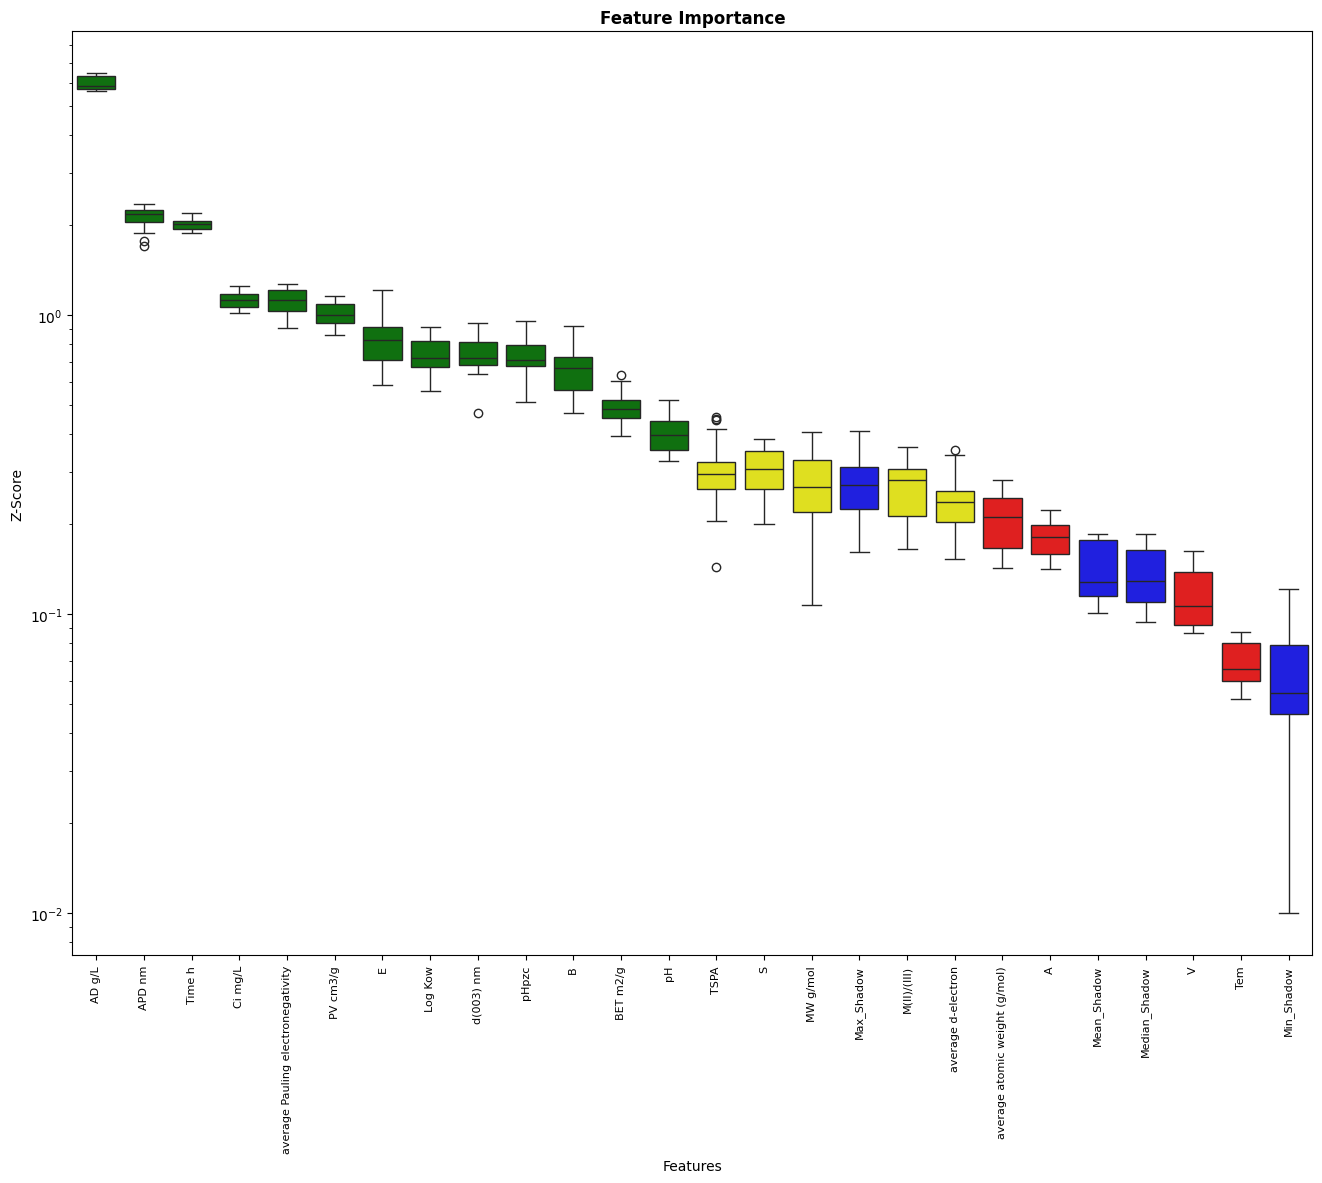

In [21]:
selector.plot(which_features="all", figsize=(16, 12))

### 5.4 Stat Correlation

In [ ]:
# # Xác định targets và features
# TARGETS = ["RR %"]
# NUMERIC_COLS = cleaned_df.select_dtypes(include="number").columns.to_list()
# FEATURES = [col for col in NUMERIC_COLS if col not in TARGETS]

# # Tính ma trận tương quan cho cả 2 method (chỉ lấy Features vs Targets)
# corr_pearson = cleaned_df[NUMERIC_COLS].corr(method="pearson").loc[FEATURES, FEATURES]
# corr_spearman = cleaned_df[NUMERIC_COLS].corr(method="spearman").loc[FEATURES, FEATURES]

# # 3. Trực quan hóa song song 2 Heatmap
# fig, axes = plt.subplots(2, 1, figsize=(14, max(6, len(FEATURES))), sharey=True)

# # Common heatmap arguments
# heatmap_kws = dict(
#     cmap="RdBu_r",
#     vmin=-1,
#     vmax=1,
#     center=0,
#     annot=True,
#     fmt=".2f",
#     linewidths=0.4,
#     annot_kws={"size": 9},
#     cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"},
# )

# # --- Subplot 1: Pearson (Linear) ---
# sns.heatmap(corr_pearson, ax=axes[0], **heatmap_kws)
# axes[0].set_title(
#     "Pearson Correlation (Linear)", fontsize=13, fontweight="bold", pad=12
# )
# axes[0].set_xlabel("Target Variables", fontweight="bold", fontsize=10)
# axes[0].tick_params(axis="x", rotation=0, labelsize=10)
# axes[0].tick_params(axis="y", labelsize=10)

# # --- Subplot 2: Spearman (Monotonic / Ranked) ---
# sns.heatmap(corr_spearman, ax=axes[1], **heatmap_kws)
# axes[1].set_title(
#     "Spearman Correlation (Monotonic / Ranked)",
#     fontsize=13,
#     fontweight="bold",
#     pad=12,
# )
# axes[1].set_xlabel("Target Variables", fontweight="bold", fontsize=10)
# axes[1].tick_params(axis="x", rotation=0, labelsize=10)
# axes[1].set_ylabel("")  # Ẩn nhãn y vì đã sharey với subplot trái

# plt.tight_layout()
# plt.show()

## 6. RR % Prediction
* Split data 80/20 and train 5 models on 5-fold cross validation.
* Models comparison: LR, KNN, Cubist, ANN, DNN, HistGradientBoostingRegressor
* MAE (càng thấp càng tốt): HistGB ⭐ > KNN > XGB > RF > Cubist > LR > ANN
* R^2 (càng cao càng tốt): HistGB ⭐> XGB > RF > KNN > Cubist >LR > ANN

In [45]:
# Removed features from BorutaShap
removed_features = [f for f in features_to_remove if (f != "V" and f != "A")]

# Statistic values of selected features
stats_df = df_imputed.drop(columns=removed_features)
stats_df = stats_df.agg(["mean", "std", "median", "min", "max", "sem", "skew"]).T
stats_df = stats_df.rename(columns={})
display(stats_df)

,mean,std,median,min,max,sem,skew
Log Kow,0.831729,2.344023,-0.020000,-2.670000,4.510000,0.063986,0.534473
MW g/mol,349.405283,97.080653,331.340000,152.150000,733.930000,2.650064,0.452887
E,2.039374,0.749201,1.810000,0.700000,3.600000,0.020451,0.764347
S,2.332757,0.711396,2.100000,0.700000,3.600000,0.019419,0.400562
A,0.834784,0.377369,0.700000,0.310000,1.650000,0.010301,0.825211
B,1.729717,0.940102,1.700000,0.450000,3.500000,0.025662,0.463207
V,2.408079,0.759751,2.304700,1.131300,6.350000,0.020739,1.980096
TSPA,101.645127,55.124987,76.200000,37.300000,194.000000,1.504777,0.579215
M(II)/(III),3.015276,1.214791,3.000000,0.500000,8.000000,0.033161,1.847467
average d-electron,3.773465,3.689140,4.250000,0.000000,8.890000,0.100705,0.068206


In [46]:
# Boruta Shap outputs but keep V
X_train_scaled = X_train.drop(columns=removed_features)
X_test_scaled = X_test.drop(columns=removed_features)

# Lấy số lượng biến đầu vào để thiết lập cho lớp ẩn của ANN
n_input_features = X_train.shape[1]

# Khởi tạo K-Fold với n_splits=5
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

# ==========================================
# 1. THIẾT LẬP PIPELINE & GRID SEARCH
# ==========================================

# --- Linear Regression ---
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

# --- KNN (Tối ưu hóa n_neighbors từ 1 đến 10 dựa trên MAE) ---
knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', KNeighborsRegressor())
])
knn__param_grid = {
    'regressor__n_neighbors': list(range(1, 10))
}
# scoring='neg_mean_absolute_error' để minimize MAE
knn_grid = GridSearchCV(knn_pipe, knn__param_grid, cv=kf, scoring='neg_mean_absolute_error', n_jobs=-1)

# --- ANN (1 lớp ẩn với ReLU, số neuron = 32) ---
ann_model = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', MLPRegressor(
        hidden_layer_sizes=(32,),
        activation='relu',
        solver='adam',
        max_iter=2000,
        random_state=SEED
    ))
])

# --- CUBIST (Tối ưu hóa committees và neighbors dựa trên MSE) ---
cubist_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', Cubist())
])
cubist__param_grid = {
    'regressor__n_committees': list(range(1, 10)),
    'regressor__neighbors': list(range(0, 9))
}
# scoring='neg_mean_squared_error' để minimize MSE
cubist_grid = GridSearchCV(cubist_pipe, cubist__param_grid, cv=kf, scoring='neg_mean_squared_error', n_jobs=-1)

# --- Tree-based models (HistGradientBoostingRegressor and XGBoost) ---
# LightGBM
def tune_lgb_optuna(X, y, cv, n_trials=30):
    """Tìm tham số tối ưu cho LightGBM Regressor"""
    print("--- Đang chạy Optuna cho LightGBM... ---")

    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 600),
            'learning_rate': trial.suggest_float('learning_rate', 0.0001, 1.0, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 15),
            'num_leaves': trial.suggest_int('num_leaves', 20, 100),
            'min_child_samples': trial.suggest_int('min_child_samples', 3, 9),
        }

        model = Pipeline([
            ('scaler', StandardScaler()),
            # verbose=-1 is highly recommended for LightGBM to prevent spamming the console with warnings
            ('regressor', LGBMRegressor(**params, random_state=SEED, n_jobs=-1, verbose=-1))
        ])

        scores = cross_val_score(model, X, y, cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1)
        return -scores.mean()

    sampler = optuna.samplers.TPESampler(seed=SEED)
    study = optuna.create_study(direction='minimize', sampler=sampler)
    study.optimize(objective, n_trials=n_trials)

    print(f"[*] LightGBM - Tìm thấy tham số tốt nhất: {study.best_params}")
    return study.best_params

# HistGradientBoostingRegressor
def tune_hgb_optuna(X, y, cv, n_trials=30):
    """Tìm tham số tối ưu cho HistGradientBoostingRegressor"""
    print("--- Đang chạy Optuna cho HistGradientBoostingRegressor... ---")

    def objective(trial):
        params = {
            'max_iter': trial.suggest_int('max_iter', 100, 600),
            # log=True rất quan trọng để Optuna phân phối đều các giá trị nhỏ (0.0001, 0.001, 0.01)
            'learning_rate': trial.suggest_float('learning_rate', 0.0001, 1.0, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 15),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 3, 9),
        }

        model = Pipeline([
            ('scaler', StandardScaler()),
            ('regressor', HistGradientBoostingRegressor(**params, random_state=SEED))
        ])

        # Đánh giá bằng Cross Validation (trả về Negative MAE)
        scores = cross_val_score(model, X, y, cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1)
        return -scores.mean()

    # Tạo study để Maximize vì scikit-learn trả về số âm cho các hàm lỗi (càng gần 0 càng tốt)
    sampler = optuna.samplers.TPESampler(seed=SEED)
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials)

    print(f"[*] HistGradientBoosting - Tìm thấy tham số tốt nhất: {study.best_params}")
    return study.best_params

# XGBoost
def tune_xgb_optuna(X, y, cv, n_trials=30):
    """Tìm tham số tối ưu cho XGBoost"""
    print("--- Đang chạy Optuna cho XGBoost... ---")

    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 600),
            'learning_rate': trial.suggest_float('learning_rate', 0.0001, 1.0, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 15),
            'min_child_weight': trial.suggest_int('min_child_weight', 3, 9),
        }

        model = Pipeline([
            ('scaler', StandardScaler()),
            ('regressor', XGBRegressor(**params, random_state=SEED, n_jobs=-1))
        ])

        scores = cross_val_score(model, X, y, cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1)
        return -scores.mean()

    sampler = optuna.samplers.TPESampler(seed=SEED)
    study = optuna.create_study(direction='minimize', sampler=sampler)
    study.optimize(objective, n_trials=n_trials)

    print(f"[*] XGBoost - Tìm thấy tham số tốt nhất: {study.best_params}")
    return study.best_params

# Random Forest
def tune_rf_optuna(X, y, cv, n_trials=30):
    """Tìm tham số tối ưu cho Random Forest Regressor"""
    print("--- Đang chạy Optuna cho Random Forest Regressor ... ---")

    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 600),
            'max_depth': trial.suggest_int('max_depth', 3, 15),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 3, 9),
        }

        model = Pipeline([
            ('scaler', StandardScaler()),
            ('regressor', RandomForestRegressor(**params, random_state=SEED, n_jobs=-1))
        ])

        scores = cross_val_score(model, X, y, cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1)
        return -scores.mean()

    sampler = optuna.samplers.TPESampler(seed=SEED)
    study = optuna.create_study(direction='minimize', sampler=sampler)
    study.optimize(objective, n_trials=n_trials)

    print(f"[*] RandomForestRegressor - Tìm thấy tham số tốt nhất: {study.best_params}")
    return study.best_params

# Chạy Optuna để lấy dict tham số (giả sử set n_trials=30 vòng cho mỗi thuật toán)
best_lgb_params = tune_lgb_optuna(X_train, y_train, cv=kf, n_trials=30)
best_hgb_params = tune_hgb_optuna(X_train, y_train, cv=kf, n_trials=30)
best_xgb_params = tune_xgb_optuna(X_train, y_train, cv=kf, n_trials=30)
best_rf_params = tune_rf_optuna(X_train, y_train, cv=kf, n_trials=30)

# Tạo Pipeline mới với tham số tối ưu vừa tìm được
optimized_lgb_model = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LGBMRegressor(**best_lgb_params, random_state=SEED, n_jobs=-1, verbose=-1))
])

optimized_hgb_model = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', HistGradientBoostingRegressor(**best_hgb_params, random_state=SEED))
])

optimized_xgb_model = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', XGBRegressor(**best_xgb_params, random_state=SEED, n_jobs=-1))
])

optimized_rf_model = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', RandomForestRegressor(**best_rf_params, random_state=SEED, n_jobs=-1))
])

# ==========================================
# 2. HUẤN LUYỆN VÀ ĐÁNH GIÁ (CROSS-VALIDATION & TEST SET)
# ==========================================

def evaluate_model(model_or_grid, X_tr, y_tr, X_te, y_te, cv, model_name, is_grid=False):
    """
    Hàm huấn luyện, đánh giá K-Fold CV trên tập Train và kiểm tra trên tập Test.
    """
    print(f"--- Đang xử lý {model_name}... ---")

    # XÁC ĐỊNH MÔ HÌNH TỐI ƯU (ESTIMATOR)
    if is_grid:
        # Chạy GridSearch để tìm tham số tốt nhất
        model_or_grid.fit(X_tr, y_tr)
        best_model = model_or_grid.best_estimator_

        # In ra cấu hình tối ưu
        clean_params = {k.replace('regressor__', ''): v for k, v in model_or_grid.best_params_.items()}
        print(f"[*] Cấu hình tối ưu tìm được: {clean_params}")
    else:
        # Chạy luôn pipeline đầu vào
        best_model = model_or_grid

    # 2. ĐÁNH GIÁ K-FOLD CV TRÊN TẬP TRAIN
    # Đánh giá metrics trên model tốt nhất
    scoring = {
        'r2': 'r2',
        'neg_mae': 'neg_mean_absolute_error',
        'neg_rmse': 'neg_root_mean_squared_error',
    }

    cv_results = cross_validate(best_model, X_tr, y_tr, cv=cv, scoring=scoring, return_train_score=False)
    cv_r2_mean = np.mean(cv_results['test_r2'])
    cv_mae_mean = -np.mean(cv_results['test_neg_mae'])
    cv_rmse_mean = -np.mean(cv_results['test_neg_rmse'])

    print(f"[*] CV (Train Set) Mean R^2 : {cv_r2_mean:.4f}")
    print(f"[*] CV (Train Set) Mean MAE : {cv_mae_mean:.4f}")
    print(f"[*] CV (Train Set) Mean RMSE : {cv_rmse_mean:.4f}")

    # 3. ĐÁNH GIÁ TRÊN TẬP TEST
    # Fit lại mô hình trên dữ liệu Train
    best_model.fit(X_tr, y_tr)

    # Dự đoán và tính điểm
    y_pred = best_model.predict(X_te)
    test_r2 = r2_score(y_te, y_pred)
    test_mae = mean_absolute_error(y_te, y_pred)
    test_rmse = root_mean_squared_error(y_te, y_pred)

    print(f"Kết quả Test Set (Hold-out):")
    print(f"    Test R^2 : {test_r2:.4f}")
    print(f"    Test MAE : {test_mae:.4f}")
    print(f"    Test RMSE : {test_rmse:.4f}\n")

    return dict(model=best_model, y_tr=y_tr, y_te=y_te, y_pred=y_pred, train_results=cv_results,
                test_r2=test_r2, test_mae=test_mae, test_rmse=test_rmse, label=model_name)

--- Đang chạy Optuna cho LightGBM... ---
[*] LightGBM - Tìm thấy tham số tốt nhất: {'n_estimators': 444, 'learning_rate': 0.06797018123180418, 'max_depth': 14, 'num_leaves': 53, 'min_child_samples': 3}
--- Đang chạy Optuna cho HistGradientBoostingRegressor... ---
[*] HistGradientBoosting - Tìm thấy tham số tốt nhất: {'max_iter': 326, 'learning_rate': 0.12139818019374735, 'max_depth': 10, 'min_samples_leaf': 3}
--- Đang chạy Optuna cho XGBoost... ---
[*] XGBoost - Tìm thấy tham số tốt nhất: {'n_estimators': 525, 'learning_rate': 0.11531894070987087, 'max_depth': 10, 'min_child_weight': 3}
--- Đang chạy Optuna cho Random Forest Regressor ... ---
[*] RandomForestRegressor - Tìm thấy tham số tốt nhất: {'n_estimators': 260, 'max_depth': 15, 'min_samples_leaf': 3}


In [47]:
X_train_scaled.shape

(939, 20)

In [48]:
# Gọi hàm cho các mô hình
res_rr_lr = evaluate_model(lr_pipe, X_train, y_train, X_test, y_test, cv=kf, model_name="LR", is_grid=False)
res_rr_knn = evaluate_model(knn_grid, X_train, y_train, X_test, y_test, cv=kf, model_name="KNN", is_grid=True)
res_rr_ann = evaluate_model(ann_model, X_train, y_train, X_test, y_test, cv=kf, model_name="ANN", is_grid=False)
res_rr_cubist = evaluate_model(cubist_grid, X_train, y_train, X_test, y_test, cv=kf, model_name="Cubist", is_grid=True)
res_rr_lgb = evaluate_model(optimized_lgb_model, X_train, y_train, X_test, y_test, cv=kf, model_name="LGB", is_grid=False)
res_rr_hgb = evaluate_model(optimized_hgb_model, X_train, y_train, X_test, y_test, cv=kf, model_name="HistGB", is_grid=False)
res_rr_xgb = evaluate_model(optimized_xgb_model, X_train, y_train, X_test, y_test, cv=kf, model_name="XGB", is_grid=False)
res_rr_rf = evaluate_model(optimized_rf_model, X_train, y_train, X_test, y_test, cv=kf, model_name="RF", is_grid=False)

--- Đang xử lý LR... ---
[*] CV (Train Set) Mean R^2 : 0.2493
[*] CV (Train Set) Mean MAE : 19.5379
[*] CV (Train Set) Mean RMSE : 23.8484
Kết quả Test Set (Hold-out):
    Test R^2 : 0.2286
    Test MAE : 20.8923
    Test RMSE : 25.0077

--- Đang xử lý KNN... ---
[*] Cấu hình tối ưu tìm được: {'n_neighbors': 1}
[*] CV (Train Set) Mean R^2 : 0.6900
[*] CV (Train Set) Mean MAE : 8.6427
[*] CV (Train Set) Mean RMSE : 15.2688
Kết quả Test Set (Hold-out):
    Test R^2 : 0.8024
    Test MAE : 6.8810
    Test RMSE : 12.6554

--- Đang xử lý ANN... ---
[*] CV (Train Set) Mean R^2 : 0.5741
[*] CV (Train Set) Mean MAE : 13.5500
[*] CV (Train Set) Mean RMSE : 17.9566
Kết quả Test Set (Hold-out):
    Test R^2 : 0.5539
    Test MAE : 13.9080
    Test RMSE : 19.0169

--- Đang xử lý Cubist... ---
[*] Cấu hình tối ưu tìm được: {'n_committees': 9, 'neighbors': 1}
[*] CV (Train Set) Mean R^2 : 0.7769
[*] CV (Train Set) Mean MAE : 8.5203
[*] CV (Train Set) Mean RMSE : 12.9939
Kết quả Test Set (Hold-out):


## 7. Best performance viz

In [51]:
# Create a Reusable Plotting Function
def build_custom_boxplot(ax, data, labels, colors, ylabel):
    # Plot base boxplot with specific flier (outlier) and mean properties
    bplot = ax.boxplot(data, labels=labels, patch_artist=True,
                       showmeans=True,
                       meanprops={"marker": "o", "markerfacecolor": "red", "markeredgecolor": "red", "markersize": 5},
                       flierprops={"marker": "o", "markerfacecolor": "none", "markeredgecolor": "darkblue", "markersize": 4})

    # Customize colors for each specific model's box
    for i, (patch, color, model_data) in enumerate(zip(bplot['boxes'], colors, data)):
        # Box styling
        patch.set_facecolor('white') # Keeps the inside hollow
        patch.set_edgecolor(color)
        patch.set_linewidth(1.5)

        # Style whiskers, caps, and median line to match the box color
        bplot['whiskers'][2*i].set(color=color, linewidth=1.5)
        bplot['whiskers'][2*i+1].set(color=color, linewidth=1.5)
        bplot['caps'][2*i].set(color=color, linewidth=1.5)
        bplot['caps'][2*i+1].set(color=color, linewidth=1.5)
        bplot['medians'][i].set(color=color, linewidth=1.5)

        # Add the floating text for the mean value
        mean_val = np.mean(model_data)
        ax.text(i + 1.15, mean_val, f"{mean_val:.3f}", color=color, va='center', fontsize=11, fontweight='bold')

    # Formatting axes
    ax.set_ylabel(ylabel, fontsize=13)
    ax.set_xlabel('Algorithms', fontsize=13)
    ax.tick_params(axis='both', labelsize=11)

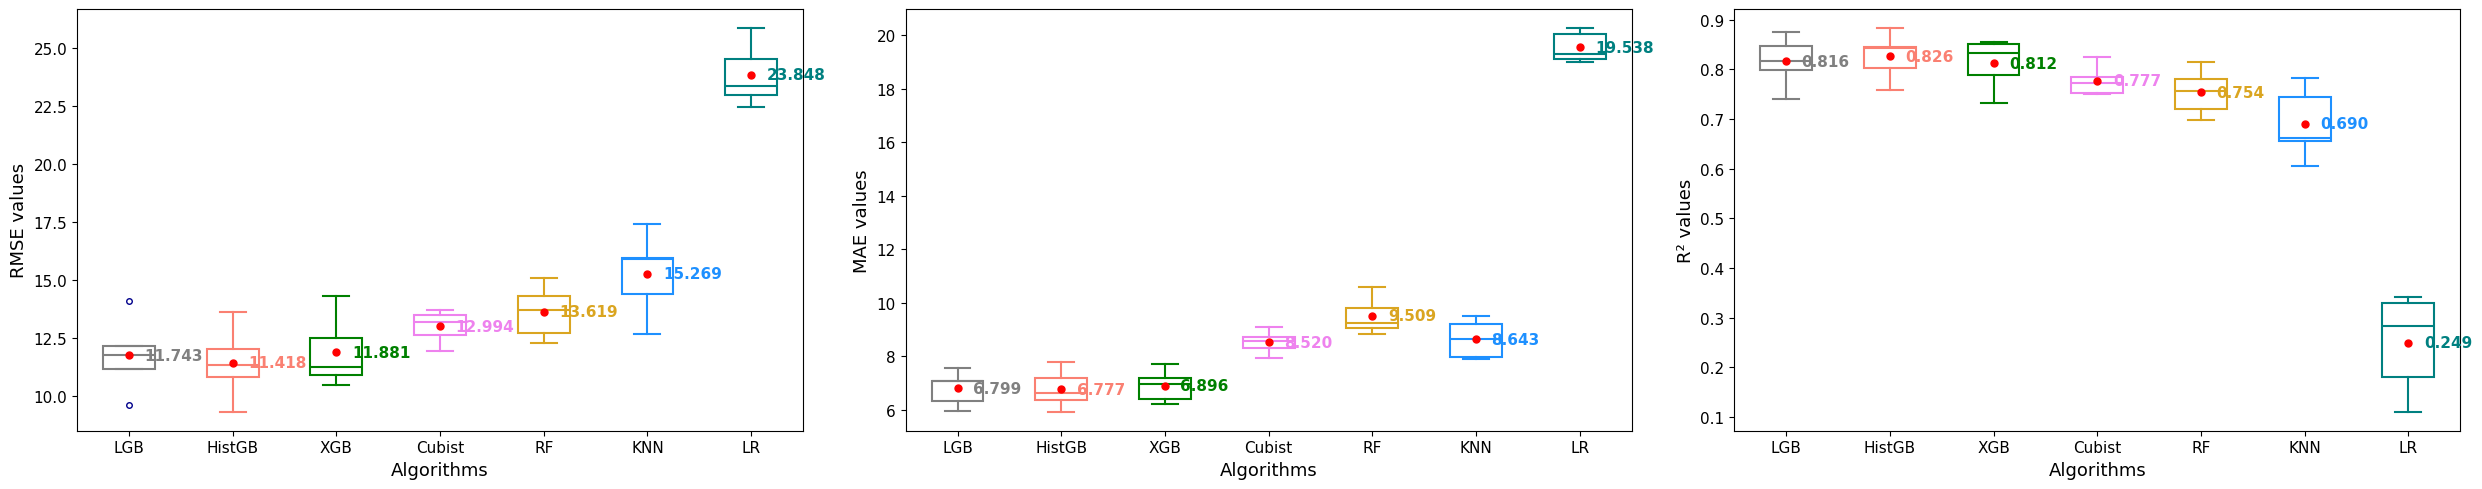

In [52]:
# Model names and colors are ready
models = ['LGB', 'HistGB', 'XGB', 'Cubist', 'RF', 'KNN', 'LR']
colors = ['gray', 'salmon', 'green', 'violet', 'goldenrod', 'dodgerblue', 'teal']

# 5-fold validation scores for model comparison
all_models_train_rmse = [
    -res_rr_lgb["train_results"]["test_neg_rmse"],
    -res_rr_hgb["train_results"]["test_neg_rmse"],
    -res_rr_xgb["train_results"]["test_neg_rmse"],
    -res_rr_cubist["train_results"]["test_neg_rmse"],
    -res_rr_rf["train_results"]["test_neg_rmse"],
    -res_rr_knn["train_results"]["test_neg_rmse"],
    -res_rr_lr["train_results"]["test_neg_rmse"]
]

all_models_train_mae = [
    -res_rr_lgb["train_results"]["test_neg_mae"],
    -res_rr_hgb["train_results"]["test_neg_mae"],
    -res_rr_xgb["train_results"]["test_neg_mae"],
    -res_rr_cubist["train_results"]["test_neg_mae"],
    -res_rr_rf["train_results"]["test_neg_mae"],
    -res_rr_knn["train_results"]["test_neg_mae"],
    -res_rr_lr["train_results"]["test_neg_mae"]
]

all_models_train_r2 = [
    res_rr_lgb["train_results"]["test_r2"],
    res_rr_hgb["train_results"]["test_r2"],
    res_rr_xgb["train_results"]["test_r2"],
    res_rr_cubist["train_results"]["test_r2"],
    res_rr_rf["train_results"]["test_r2"],
    res_rr_knn["train_results"]["test_r2"],
    res_rr_lr["train_results"]["test_r2"]
]

# Visualize
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(25, 5))

# Plotting the extracted Test MAE and Test R2
build_custom_boxplot(ax1, all_models_train_rmse, models, colors, 'RMSE values')
build_custom_boxplot(ax2, all_models_train_mae, models, colors, 'MAE values')
build_custom_boxplot(ax3, all_models_train_r2, models, colors, 'R² values')

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Green-X Project/Model/train_scores.png", dpi=300)
plt.show()

HistGB Performance

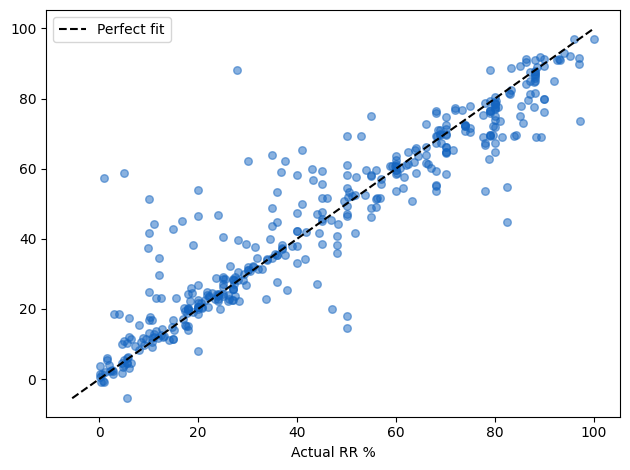

In [53]:
label = 'RR %'
# Manual label
y_t, y_p = res_rr_lgb['y_te'], res_rr_hgb['y_pred']
color = '#1565C0'
# Actual vs Predicted
plt.scatter(y_t, y_p, alpha=0.5, s=30, color=color)
lo, hi = min(y_t.min()[0], y_p.min()), max(y_t.max()[0], y_p.max())
plt.plot([lo,hi],[lo,hi],'k--',lw=1.5,label='Perfect fit')
plt.xlabel(f'Actual {label}'); ax.set_ylabel(f'Predicted {label}')
plt.legend(); plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Green-X Project/Model/model_results.png", dpi=300)
plt.show()

## 8. Save model artifacts

In [54]:
import joblib

In [55]:
trained_artifacts = {
    "LR": res_rr_lr,
    "KNN": res_rr_knn,
    "ANN": res_rr_ann,
    "Cubist": res_rr_cubist,
    "HistGB": res_rr_hgb,
    "XGB": res_rr_xgb,
    "RF": res_rr_rf
}

# Save the entire dictionary to a single file
joblib.dump(trained_artifacts, '/content/drive/MyDrive/Green-X Project/Model/saved_artifacts.joblib')
print("All models successfully saved to 'saved_models.joblib'")

All models successfully saved to 'saved_models.joblib'


## 9. Permutation Importance – Tổng hợp & So sánh
* Permutation Importance for LR, XGB, RF, HistGB, Cubist

$\rightarrow$ Linear Regression as the most robust to noise


In [56]:
from sklearn.inspection import permutation_importance
import shap

In [57]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
import copy

def extract_feature_ranks(model, feature_names, X_df, y_df):
    """
    Hàm trích xuất và xếp hạng độ quan trọng của biến từ các loại mô hình khác nhau.
    Rank 1 = Quan trọng nhất.
    """
    X_selected = X_df[feature_names]
    # Assuming 'model' is a Pipeline. permutation_importance can take a pipeline directly.
    result = permutation_importance(model, X_selected, y_df, n_repeats=10, random_state=SEED, n_jobs=-1)
    importances = result.importances_mean
    # Chuyển importances thành DataFrame để dễ xếp hạng (Ranking)
    df_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

    # Xếp hạng: Giá trị lớn nhất -> Rank 1
    df_imp['Rank'] = df_imp['Importance'].rank(ascending=False, method='min')

    return df_imp.set_index('Feature')['Rank'].to_dict()


def evaluate_feature_importance_methods(X, y, base_models):
    """
    Tiêm nhiễu với các scale khác nhau và theo dõi thứ hạng của biến 'random'.
    """
    scales = [0.001, 10, 1000]
    results = []

    for scale in scales:
        print(f"--- Đang kiểm thử với Noise Scale: {scale} ---")

        # 1. Convert X (numpy array) to a DataFrame to allow adding the 'random_noise' column
        X_noisy_df = X.copy() # Now X_noisy_df is a DataFrame

        # Tạo dữ liệu ngẫu nhiên phân phối chuẩn, sau đó nhân với scale
        np.random.seed(SEED) # Use global SEED
        X_noisy_df['random_noise'] = np.random.randn(len(X)) * scale

        features_noisy = X_noisy_df.columns.tolist()

        # 2. Huấn luyện và trích xuất thứ hạng cho từng mô hình
        for model_name, model_info in base_models.items():
            regressor = model_info['model']

            # Create a deep copy of the model pipeline to avoid modifying the original
            test_regressor = copy.deepcopy(regressor)

            # Huấn luyện trên tập dữ liệu đã có nhiễu (DataFrame)
            # The pipeline 'test_regressor' is expected to handle scaling internally if needed.
            test_regressor.fit(X_noisy_df, y)

            # Trích xuất xếp hạng - Pass the DataFrame with noise and its feature names
            ranks = extract_feature_ranks(test_regressor, features_noisy, X_noisy_df, y)

            # Lưu lại kết quả thứ hạng của riêng biến 'random_noise'
            noise_rank = ranks.get('random_noise', np.nan) # Use .get to avoid KeyError if 'random_noise' is somehow missing

            results.append({
                'Model': model_name,
                'Noise Scale': scale,
                'Noise Rank': noise_rank
            })

    # Chuyển kết quả thành DataFrame để dễ nhìn
    results_df = pd.DataFrame(results)
    pivot_results = results_df.pivot(index='Model', columns='Noise Scale', values='Noise Rank')

    print(f"\n[ KẾT QUẢ ] Thứ hạng của biến nhiễu 'random_noise' (Rank 1 là quan trọng nhất, Rank {X_noisy_df.shape[1]} là kém nhất)")
    print(pivot_results)
    return pivot_results

In [61]:
# Khai báo dictionary chứa các mô hình cần đánh giá
models_to_test_rr = {
    'Linear Regression': {
        'model': res_rr_lr["model"],
        'type': 'LR'
    },
    'KNN': {
        'model': res_rr_knn["model"],
        'type': 'KNN'
    },
    'Cubist': {
        'model': res_rr_cubist["model"],
        'type': 'Cubist'
    },
    'LightGBM': {
        'model': res_rr_lgb["model"],
        'type': 'LightGBM'
    },
    'HistGradientBoosting': {
        'model': res_rr_hgb["model"],
        'type': 'HistGB'
    },
    'Random Forest': {
        'model': res_rr_rf["model"],
        'type': 'RF'
    },
    'XGBoost': {
        'model': res_rr_xgb["model"],
        'type': 'XGB'
    },
}

# Chạy thử nghiệm
pivot_table_rr = evaluate_feature_importance_methods(X_train_scaled, y_train, models_to_test_rr)

# Save result table
pivot_table_rr.to_csv("/content/drive/MyDrive/Green-X Project/Model/permutation_importance.csv", index=False)

print(pivot_table_rr)

--- Đang kiểm thử với Noise Scale: 0.001 ---
--- Đang kiểm thử với Noise Scale: 10 ---
--- Đang kiểm thử với Noise Scale: 1000 ---

[ KẾT QUẢ ] Thứ hạng của biến nhiễu 'random_noise' (Rank 1 là quan trọng nhất, Rank 21 là kém nhất)
Noise Scale           0.001     10.000    1000.000
Model                                             
Cubist                     6.0       6.0       6.0
HistGradientBoosting       6.0       6.0       6.0
KNN                        1.0       1.0       1.0
LightGBM                   7.0       7.0       7.0
Linear Regression         21.0      21.0      21.0
Random Forest              9.0       9.0       9.0
XGBoost                    8.0       8.0       8.0
Noise Scale           0.001     10.000    1000.000
Model                                             
Cubist                     6.0       6.0       6.0
HistGradientBoosting       6.0       6.0       6.0
KNN                        1.0       1.0       1.0
LightGBM                   7.0       7.0       7.0
Lin

In [60]:
lr_rank_rr = extract_feature_ranks(res_rr_lr["model"], X_train_scaled.columns, X_train_scaled, y_train)
rank_df_rr = pd.Series(lr_rank_rr).to_frame(name='Rank').sort_values(by="Rank")
print(rank_df_rr)

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- Tem
- average atomic weight (g/mol)


In [ ]:
xgb_rank_rr = extract_feature_ranks(res_rr_xgb["model"], X_train_scaled.columns, X_train_scaled, y_train)
rank_df_rr = pd.Series(xgb_rank_rr).to_frame(name='Rank').sort_values(by="Rank")
print(rank_df_rr)

                                   Rank
AD g/L                              1.0
Time h                              2.0
APD nm                              3.0
Ci mg/L                             4.0
pH                                  5.0
MW g/mol                            6.0
BET m2/g                            7.0
d(003) nm                           8.0
Log Kow                             9.0
pHpzc                              10.0
PV cm3/g                           11.0
average atomic weight (g/mol)      12.0
E                                  13.0
S                                  14.0
average Pauling electronegativity  15.0
V                                  16.0
B                                  17.0
average d-electron                 18.0
A                                  19.0


PermutationExplainer explainer: 270it [02:17,  1.87it/s]


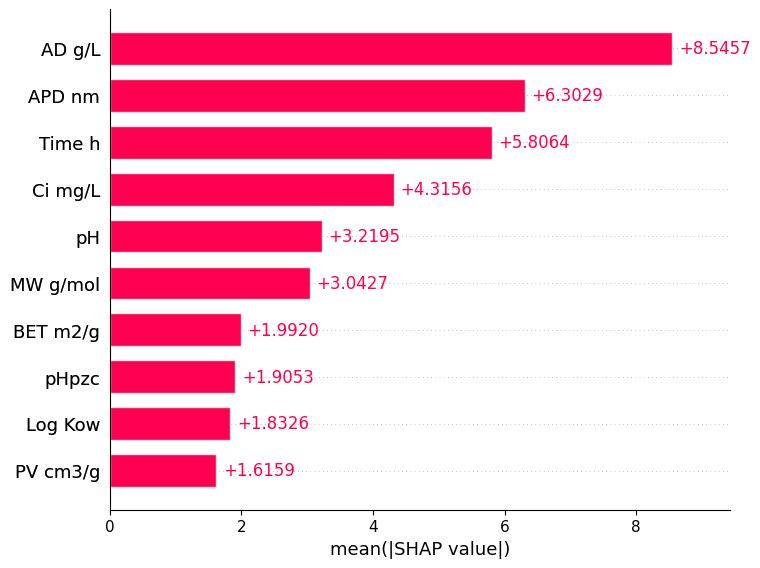

In [ ]:
# Create a background dataset from X_train (100-200 rows is optimal for speed)
background_data = shap.sample(X_train_scaled, 1342)

# Pass the .predict method explicitly for regression models
explainer_rr_xgb = shap.Explainer(res_rr_xgb["model"].predict, background_data)

# Compute SHAP values strictly on the test set (or a subset of test set)
shap_values_rr = explainer_rr_xgb(X_test_scaled)

mean_shap_values = np.abs(shap_values_rr.values).mean(axis=0)
top_10_indices = np.argsort(mean_shap_values)[-10:]

# 3. Slice the SHAP Explanation object to keep ONLY those 10 features
shap_values_top_10 = shap_values_rr[:, top_10_indices]

# Generate the plot but do not show it yet
shap.plots.bar(shap_values_top_10, max_display=10, show=False)

# Get the current axes so we can modify the labels
ax = plt.gca()

# Iterate through the bars (patches) and the text labels simultaneously
for patch, text in zip(ax.patches, ax.texts):
    # Get the actual numeric value (the width of the bar)
    true_value = patch.get_width()

    # Update the text label to show 4 decimal places
    text.set_text(f"+{true_value:.4f}")

# Save and show
plt.savefig('/content/drive/MyDrive/Green-X Project/Model/shap_bar_plot.png', dpi=300, bbox_inches='tight')
plt.show()